In [1]:
import pandas as pd
import tensorflow as tf
import numpy as np
import gc
import time
#import matplotlib.pyplot as plt
#from livelossplot.keras import PlotLossesCallback
from tensorflow.keras.callbacks import ReduceLROnPlateau
#from keras.models import load_model
import csv
from itertools import chain
from matplotlib import pyplot as plt

D:\ProgramData\Anaconda3\envs\tensorflow210\lib\site-packages\tensorflow\python\framework\dtypes.py:516: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
D:\ProgramData\Anaconda3\envs\tensorflow210\lib\site-packages\tensorflow\python\framework\dtypes.py:517: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
D:\ProgramData\Anaconda3\envs\tensorflow210\lib\site-packages\tensorflow\python\framework\dtypes.py:518: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16, 1)])
D:\ProgramData\Anaconda3\envs\tensorflow210\lib\s

### 设置GPU显存按需分配

In [2]:
#如果没有装GPU版本，这部分就不用写，但是如果不用GPU加速计算，使用CPU将会严重限制模型的训练速度
gpus = tf.config.experimental.list_physical_devices('GPU') 
if gpus:
  try:

    for gpu in gpus:
      tf.config.experimental.set_memory_growth(gpu, True)
    logical_gpus = tf.config.experimental.list_logical_devices('GPU')
    print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
  except RuntimeError as e:

    print(e)

1 Physical GPUs, 1 Logical GPUs


### 载入数据

In [3]:
data_train=pd.read_csv('F:/TensorFlow/traindata20240314.csv',header=0,encoding='utf_8')
data_train.info()
data_train.ClassName.unique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9001 entries, 0 to 9000
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         9001 non-null   object 
 1   corn       9001 non-null   int64  
 2   wheat      9001 non-null   int64  
 3   ClassName  9001 non-null   int64  
 4   SR_B1      9001 non-null   float64
 5   SR_B2      9001 non-null   float64
 6   SR_B3      9001 non-null   float64
 7   SR_B4      9001 non-null   float64
 8   SR_B5      9001 non-null   float64
 9   ST_B6      9001 non-null   float64
 10  SR_B7      9001 non-null   float64
 11  x          9001 non-null   float64
 12  y          9001 non-null   float64
dtypes: float64(9), int64(3), object(1)
memory usage: 914.3+ KB


array([0, 1], dtype=int64)

In [4]:
pd.set_option('display.max_rows', None)
print(data_train['ClassName'].value_counts())

0    5497
1    3504
Name: ClassName, dtype: int64


In [5]:
data_train.head()

,id,corn,wheat,ClassName,SR_B1,SR_B2,SR_B3,SR_B4,SR_B5,ST_B6,SR_B7,x,y
0,JN-01-0707-1,1,0,0,0.055365,0.086028,0.096367,0.262962,0.151560,296.921651,0.099723,116.908745,36.763915
1,JN-01-0707-2,1,0,0,0.065568,0.103627,0.119220,0.250395,0.180517,294.501693,0.121942,116.907599,36.760050
2,JN-01-0707-3,1,0,0,0.062598,0.097193,0.102417,0.274485,0.179115,298.531539,0.119523,116.906762,36.763065
3,JN-01-0707-4,1,0,0,0.061663,0.099613,0.100245,0.283285,0.217065,294.084695,0.129340,116.898303,36.759707
4,JN-01-0708-4,1,0,0,0.058967,0.091033,0.109018,0.287355,0.204113,295.930426,0.124280,117.057983,36.774082


In [6]:
# 生成该区间的随意唯一索引
index = np.random.permutation(len(data_train))
# 用生成的乱的索引就能将其打乱了
data_all = data_train.iloc[index ,:]

### 切分数据

In [7]:
split_index = int(len(data_all)*0.7)
data_train = data_all.iloc[:split_index]

data_test = data_all.iloc[split_index:]
data_test.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2701 entries, 3266 to 3150
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         2701 non-null   object 
 1   corn       2701 non-null   int64  
 2   wheat      2701 non-null   int64  
 3   ClassName  2701 non-null   int64  
 4   SR_B1      2701 non-null   float64
 5   SR_B2      2701 non-null   float64
 6   SR_B3      2701 non-null   float64
 7   SR_B4      2701 non-null   float64
 8   SR_B5      2701 non-null   float64
 9   ST_B6      2701 non-null   float64
 10  SR_B7      2701 non-null   float64
 11  x          2701 non-null   float64
 12  y          2701 non-null   float64
dtypes: float64(9), int64(3), object(1)
memory usage: 295.4+ KB


In [8]:
train_x = data_train.iloc[:,4:]
train_y = data_train.loc[:, ['ClassName']] 

test_x = data_test.iloc[:,4:]
test_y = data_test.loc[:, ['ClassName']] 
train_x.head(), train_y.head()

(         SR_B1     SR_B2     SR_B3     SR_B4     SR_B5       ST_B6     SR_B7  \
 3857  0.103517  0.145537  0.187722  0.240000  0.322885  298.958792  0.273220   
 1942  0.080541  0.093796  0.102472  0.287135  0.201775  291.097346  0.131361   
 8768  0.095845  0.139405  0.167428  0.303305  0.278253  297.687288  0.210300   
 1195  0.063299  0.077118  0.092985  0.235875  0.171525  287.607547  0.115782   
 1641  0.116278  0.140890  0.163440  0.232822  0.260680  273.080962  0.212143   
 
                x          y  
 3857  104.090631  36.731060  
 1942  108.307021  34.508192  
 8768  108.463410  41.192332  
 1195  111.648234  36.068688  
 1641  107.281231  35.585847  ,
       ClassName
 3857          0
 1942          0
 8768          1
 1195          0
 1641          0)

### 类别数量

In [7]:
num_classes = data_train['ClassName'].nunique()
print(num_classes)

2


### 不测试时使用全部数据训练

In [8]:
train_x = data_train.iloc[:,4:]
train_y = data_train.loc[:, ['ClassName']] 

In [9]:
train_x.head()

,SR_B1,SR_B2,SR_B3,SR_B4,SR_B5,ST_B6,SR_B7,x,y
0,0.055365,0.086028,0.096367,0.262962,0.151560,296.921651,0.099723,116.908745,36.763915
1,0.065568,0.103627,0.119220,0.250395,0.180517,294.501693,0.121942,116.907599,36.760050
2,0.062598,0.097193,0.102417,0.274485,0.179115,298.531539,0.119523,116.906762,36.763065
3,0.061663,0.099613,0.100245,0.283285,0.217065,294.084695,0.129340,116.898303,36.759707
4,0.058967,0.091033,0.109018,0.287355,0.204113,295.930426,0.124280,117.057983,36.774082


### 顺序编码转独热编码

In [10]:
train_y = tf.keras.utils.to_categorical(train_y)

In [11]:
train_x.head()
train_y

array([[1., 0.],
       [1., 0.],
       [1., 0.],
       ...,
       [0., 1.],
       [0., 1.],
       [0., 1.]], dtype=float32)

### 定义损失函数为Focal Loss

In [12]:
def multi_category_focal_loss2(gamma=2., alpha=.25):
    """
    focal loss for multi category of multi label problem
    适用于多分类或多标签问题的focal loss
    alpha控制真值y_true为1/0时的权重
        1的权重为alpha, 0的权重为1-alpha
    当你的模型欠拟合，学习存在困难时，可以尝试适用本函数作为loss
    当模型过于激进(无论何时总是倾向于预测出1),尝试将alpha调小
    当模型过于惰性(无论何时总是倾向于预测出0,或是某一个固定的常数,说明没有学到有效特征)
        尝试将alpha调大,鼓励模型进行预测出1。
    Usage:
     model.compile(loss=[multi_category_focal_loss2(alpha=0.25, gamma=2)], metrics=["accuracy"], optimizer='adam')
    """
    epsilon = 1.e-7
    gamma = float(gamma)
    alpha = tf.constant(alpha, dtype=tf.float32)

    def multi_category_focal_loss2_fixed(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)
    
        alpha_t = y_true*alpha + (tf.ones_like(y_true)-y_true)*(1-alpha)
        y_t = tf.multiply(y_true, y_pred) + tf.multiply(1-y_true, 1-y_pred)
        y_t = tf.clip_by_value(y_t, epsilon, 1. - epsilon)#这句是后加的
        ce = -tf.math.log(y_t)
        weight = tf.math.pow(tf.subtract(1., y_t), gamma)
        fl = tf.multiply(tf.multiply(weight, ce), alpha_t)
        loss = tf.reduce_mean(fl)
        return loss
    return multi_category_focal_loss2_fixed

### 模型构建

In [13]:
model = tf.keras.Sequential()
model.add(tf.keras.layers.Dense(1024,input_dim=9))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(512,activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(256,activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(128,activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(64,activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(32,activation='relu'))#注：如果后面再加16，8，16，32这样的全连结层，精度反而会变低
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(16,activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(8,activation='relu'))
model.add(tf.keras.layers.Dropout(rate=0.5))
model.add(tf.keras.layers.Dense(num_classes, activation='softmax'))#不懂为啥有时候对不上非要+1
# 让学习率自动变化
reduce_lr = ReduceLROnPlateau(monitor='loss',factor=0.1, patience=20, mode='auto')
model.compile(loss='categorical_crossentropy', metrics=['acc'], optimizer='adam')#adam优化
#顺序编码用loss='sparse_categorical_crossentropy'
#独热编码用loss='categorical_crossentropy'
tf.random.set_random_seed(1024)
model.summary()

Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 1024)              10240     
_________________________________________________________________
batch_normalization (BatchNo (None, 1024)              4096      
_________________________________________________________________
dense_1 (Dense)              (None, 512)               524800    
_________________________________________________________________
batch_normalization_1 (Batch (None, 512)               2048      
_________________________________________________________________
dense_2 (Dense)              (None, 256)               131328    
_________________________________________________________________
batch_normalization_2 (Batch (None, 256)               1024      
___

### 开始训练

In [14]:
e = 300
start = time.perf_counter()#time.process_time()测的时间偏长
history = model.fit(train_x,train_y, epochs=e,batch_size=32,verbose=1,callbacks=[reduce_lr])#callbacks=[reduce_lr],batch_size=16,validation_data=(validation_x,validation_y)
mins, secs = divmod((time.perf_counter() - start), 60)
hours, mins = divmod(mins, 60)
print("用时：%02d:%02d:%02d"% (hours, mins, secs))

Epoch 1/300
9001/9001 [==============================] - 3s 386us/sample - loss: 0.6489 - acc: 0.6548
Epoch 2/300
9001/9001 [==============================] - 2s 236us/sample - loss: 0.5532 - acc: 0.7239
Epoch 3/300
9001/9001 [==============================] - 2s 258us/sample - loss: 0.5349 - acc: 0.7333
Epoch 4/300
9001/9001 [==============================] - 3s 283us/sample - loss: 0.5150 - acc: 0.7485
Epoch 5/300
9001/9001 [==============================] - 2s 238us/sample - loss: 0.5222 - acc: 0.7339
Epoch 6/300
9001/9001 [==============================] - 2s 238us/sample - loss: 0.5064 - acc: 0.7495
Epoch 7/300
9001/9001 [==============================] - 2s 228us/sample - loss: 0.5058 - acc: 0.7459
Epoch 8/300
9001/9001 [==============================] - 2s 233us/sample - loss: 0.4969 - acc: 0.7578
Epoch 9/300
9001/9001 [==============================] - 2s 227us/sample - loss: 0.4881 - acc: 0.7501
Epoch 10/300
9001/9001 [==============================] - 2s 261us/sample - loss: 

9001/9001 [==============================] - 2s 234us/sample - loss: 0.3348 - acc: 0.8519
Epoch 160/300
9001/9001 [==============================] - 2s 236us/sample - loss: 0.3482 - acc: 0.8432
Epoch 161/300
9001/9001 [==============================] - 2s 239us/sample - loss: 0.3468 - acc: 0.8469
Epoch 162/300
9001/9001 [==============================] - 2s 234us/sample - loss: 0.3302 - acc: 0.8507
Epoch 163/300
9001/9001 [==============================] - 2s 230us/sample - loss: 0.3406 - acc: 0.8508
Epoch 164/300
9001/9001 [==============================] - 2s 233us/sample - loss: 0.3362 - acc: 0.8517
Epoch 165/300
9001/9001 [==============================] - 2s 232us/sample - loss: 0.3475 - acc: 0.8458
Epoch 166/300
9001/9001 [==============================] - 2s 234us/sample - loss: 0.3319 - acc: 0.8519
Epoch 167/300
9001/9001 [==============================] - 2s 236us/sample - loss: 0.3354 - acc: 0.8492
Epoch 168/300
9001/9001 [==============================] - 2s 239us/sample - l

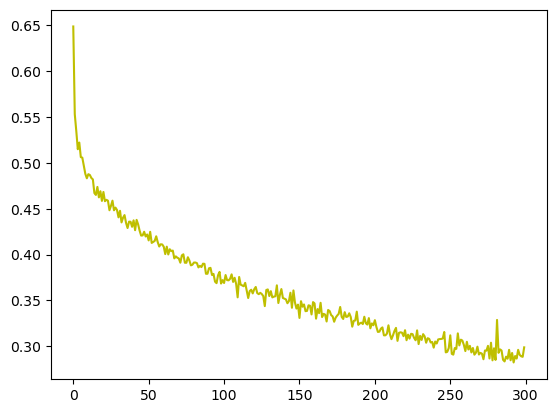

In [15]:
plt.plot(range(300),history.history.get('loss'),color =  'y')

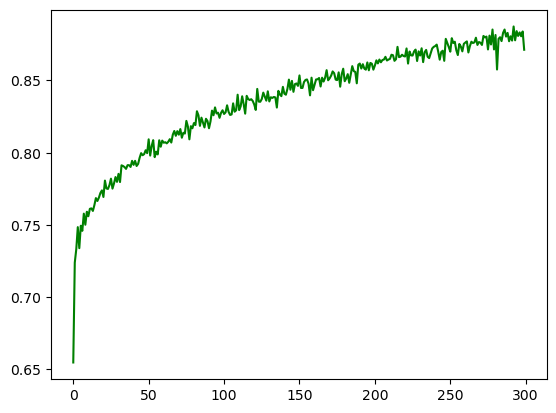

In [16]:
plt.plot(range(300),history.history.get('acc'),color =  'g')

In [17]:
model.save(r'F:/TensorFlow/model_data/model_YR_20240314.h5')

### 计算准确率

In [15]:
test_r = pd.DataFrame(model.predict_classes(test_x,verbose=1))
test_r = test_r.values
acc_array = (test_y == test_r)
print('准确率：', np.sum(acc_array!=0)/len(acc_array))

2701/2701 [==============================] - 0s 121us/sample
准确率： ClassName    0.692336
dtype: float64


### 各类别准确率

In [19]:
test_y = list(chain.from_iterable(test_y))
test_r = list(chain.from_iterable(test_r))

def count_nums(true_labels, num_classes):
    initial_value = 0
    list_length = num_classes
    list_data = [ initial_value for i in range(list_length)]
    for i in range(0, num_classes):
        list_data[i] = true_labels.count(i)
    return list_data

def accuracy(confusion_matrix, true_labels, num_classes):
    # 各个类别的测试样本的个数
    list_data = count_nums(true_labels, num_classes)
 
    # 各个类别正确分类的个数
    initial_value = 0
    list_length = num_classes
    true_pred = [ initial_value for i in range(list_length)]
    for i in range(0,num_classes):
        true_pred[i] = confusion_matrix[i][i]
 
    # 计算各个样本被正确分类的正确率
    classveg = []
    acc = []
    for i in range(0, num_classes):
        classveg.append(0)
        acc.append(0)
 
    for i in range(0,num_classes):
        classveg[i] = i
        acc[i] = float(true_pred[i] / list_data[i])
    
    z = pd.DataFrame(list(zip(classveg,acc,list_data)), columns=['class_code', 'acc','count'])
    return z

op = tf.math.confusion_matrix(test_y, test_r)

acc = accuracy(op, test_y, num_classes)
print(acc)

NameError: name 'test_y' is not defined

### 出结果

In [18]:
gc.collect()
def predict(file):
    #mylist = []
    index=0
    for chunk in pd.read_csv(file, chunksize=100000):
        print(index)
        rchunk = pd.DataFrame(model.predict_classes(chunk,verbose=1))
        #mylist.append(rchunk)
        arry1 = np.array(rchunk) #先转成np数据
        list1 = arry1.tolist()  #再转成list
        with open('F:/TensorFlow/testresult20240314_2003.csv','a',newline='',encoding='utf-8') as f:
          writer = csv.writer(f)
          writer.writerows(list1)
        index+=1
    #temp_df = pd.concat(mylist, axis= 0)
    #del mylist
    #return temp_df

start = time.perf_counter()
f = open('E:/yellow_river_20240131/2003all.txt',encoding='utf-8')#p2 ,encoding='gb2312'
prediction = predict(f)
#np.savetxt("testresult20200523caoyuan.csv", prediction, fmt="%d",delimiter=",") 
mins, secs = divmod((time.perf_counter() - start), 60)
hours, mins = divmod(mins, 60)
print("用时：%02d:%02d:%02d"% (hours, mins, secs))

0
100000/100000 [==============================] - 4s 37us/sample
1
100000/100000 [==============================] - 3s 34us/sample
2
100000/100000 [==============================] - 3s 32us/sample
3
100000/100000 [==============================] - 3s 34us/sample
4
100000/100000 [==============================] - 3s 33us/sample
5
100000/100000 [==============================] - 3s 33us/sample
6
100000/100000 [==============================] - 3s 33us/sample
7
100000/100000 [==============================] - 3s 33us/sample
8
100000/100000 [==============================] - 3s 33us/sample
9
100000/100000 [==============================] - 3s 33us/sample
10
100000/100000 [==============================] - 3s 33us/sample
11
100000/100000 [==============================] - 3s 31us/sample
12
100000/100000 [==============================] - 3s 32us/sample
13
100000/100000 [==============================] - 3s 32us/sample
14
100000/100000 [==============================] - 3s 32us/sample
15
10

100000/100000 [==============================] - 3s 32us/sample
243
100000/100000 [==============================] - 3s 32us/sample
244
100000/100000 [==============================] - 3s 32us/sample
245
100000/100000 [==============================] - 3s 32us/sample
246
100000/100000 [==============================] - 3s 33us/sample
247
100000/100000 [==============================] - 3s 32us/sample
248
100000/100000 [==============================] - 3s 32us/sample
249
100000/100000 [==============================] - 3s 32us/sample
250
100000/100000 [==============================] - 3s 32us/sample
251
100000/100000 [==============================] - 3s 35us/sample
252
100000/100000 [==============================] - 4s 35us/sample
253
100000/100000 [==============================] - 3s 34us/sample
254
100000/100000 [==============================] - 4s 35us/sample
255
100000/100000 [==============================] - 3s 34us/sample
256
100000/100000 [==============================] -

In [19]:
gc.collect()
def predict(file):
    #mylist = []
    index=0
    for chunk in pd.read_csv(file, chunksize=100000):
        print(index)
        rchunk = pd.DataFrame(model.predict_classes(chunk,verbose=1))
        #mylist.append(rchunk)
        arry1 = np.array(rchunk) #先转成np数据
        list1 = arry1.tolist()  #再转成list
        with open('F:/TensorFlow/testresult20240314_2008.csv','a',newline='',encoding='utf-8') as f:
          writer = csv.writer(f)
          writer.writerows(list1)
        index+=1
    #temp_df = pd.concat(mylist, axis= 0)
    #del mylist
    #return temp_df

start = time.perf_counter()
f = open('E:/yellow_river_20240131/2008all.txt',encoding='utf-8')#p2 ,encoding='gb2312'
prediction = predict(f)
#np.savetxt("testresult20200523caoyuan.csv", prediction, fmt="%d",delimiter=",") 
mins, secs = divmod((time.perf_counter() - start), 60)
hours, mins = divmod(mins, 60)
print("用时：%02d:%02d:%02d"% (hours, mins, secs))

0
100000/100000 [==============================] - 3s 31us/sample
1
100000/100000 [==============================] - 3s 33us/sample
2
100000/100000 [==============================] - 3s 32us/sample
3
100000/100000 [==============================] - 3s 32us/sample
4
100000/100000 [==============================] - 3s 32us/sample
5
100000/100000 [==============================] - 3s 32us/sample
6
100000/100000 [==============================] - 3s 32us/sample
7
100000/100000 [==============================] - 3s 32us/sample
8
100000/100000 [==============================] - 3s 31us/sample
9
100000/100000 [==============================] - 3s 32us/sample
10
100000/100000 [==============================] - 3s 32us/sample
11
100000/100000 [==============================] - 3s 33us/sample
12
100000/100000 [==============================] - 3s 32us/sample
13
100000/100000 [==============================] - 3s 32us/sample
14
100000/100000 [==============================] - 3s 32us/sample
15
10

100000/100000 [==============================] - 3s 32us/sample
243
100000/100000 [==============================] - 3s 35us/sample
244
100000/100000 [==============================] - 3s 33us/sample
245
100000/100000 [==============================] - 3s 33us/sample
246
100000/100000 [==============================] - 3s 32us/sample
247
100000/100000 [==============================] - 3s 32us/sample
248
100000/100000 [==============================] - 3s 33us/sample
249
100000/100000 [==============================] - 3s 32us/sample
250
100000/100000 [==============================] - 3s 33us/sample
251
100000/100000 [==============================] - 3s 32us/sample
252
100000/100000 [==============================] - 3s 32us/sample
253
100000/100000 [==============================] - 3s 32us/sample
254
100000/100000 [==============================] - 3s 34us/sample
255
100000/100000 [==============================] - 3s 33us/sample
256
100000/100000 [==============================] -

In [20]:
gc.collect()
def predict(file):
    #mylist = []
    index=0
    for chunk in pd.read_csv(file, chunksize=100000):
        print(index)
        rchunk = pd.DataFrame(model.predict_classes(chunk,verbose=1))
        #mylist.append(rchunk)
        arry1 = np.array(rchunk) #先转成np数据
        list1 = arry1.tolist()  #再转成list
        with open('F:/TensorFlow/testresult20240314_2013.csv','a',newline='',encoding='utf-8') as f:
          writer = csv.writer(f)
          writer.writerows(list1)
        index+=1
    #temp_df = pd.concat(mylist, axis= 0)
    #del mylist
    #return temp_df

start = time.perf_counter()
f = open('E:/yellow_river_20240131/2013all.csv',encoding='utf-8')#p2 ,encoding='gb2312'
prediction = predict(f)
#np.savetxt("testresult20200523caoyuan.csv", prediction, fmt="%d",delimiter=",") 
mins, secs = divmod((time.perf_counter() - start), 60)
hours, mins = divmod(mins, 60)
print("用时：%02d:%02d:%02d"% (hours, mins, secs))

0
100000/100000 [==============================] - 3s 34us/sample
1
100000/100000 [==============================] - 3s 33us/sample
2
100000/100000 [==============================] - 3s 33us/sample
3
100000/100000 [==============================] - 3s 33us/sample
4
100000/100000 [==============================] - 3s 33us/sample
5
100000/100000 [==============================] - 3s 33us/sample
6
100000/100000 [==============================] - 3s 34us/sample
7
100000/100000 [==============================] - 4s 39us/sample
8
100000/100000 [==============================] - 3s 33us/sample
9
100000/100000 [==============================] - 3s 34us/sample
10
100000/100000 [==============================] - 3s 33us/sample
11
100000/100000 [==============================] - 3s 33us/sample
12
100000/100000 [==============================] - 3s 33us/sample
13
100000/100000 [==============================] - 3s 34us/sample
14
100000/100000 [==============================] - 3s 33us/sample
15
10

100000/100000 [==============================] - 3s 33us/sample
243
100000/100000 [==============================] - 3s 34us/sample
244
100000/100000 [==============================] - 3s 34us/sample
245
100000/100000 [==============================] - 3s 34us/sample
246
100000/100000 [==============================] - 3s 34us/sample
247
100000/100000 [==============================] - 4s 38us/sample
248
100000/100000 [==============================] - 3s 34us/sample
249
100000/100000 [==============================] - 3s 34us/sample
250
100000/100000 [==============================] - 3s 33us/sample
251
100000/100000 [==============================] - 3s 34us/sample
252
100000/100000 [==============================] - 3s 34us/sample
253
100000/100000 [==============================] - 3s 34us/sample
254
100000/100000 [==============================] - 3s 34us/sample
255
100000/100000 [==============================] - 3s 34us/sample
256
100000/100000 [==============================] -

In [21]:
gc.collect()
def predict(file):
    #mylist = []
    index=0
    for chunk in pd.read_csv(file, chunksize=100000):
        print(index)
        rchunk = pd.DataFrame(model.predict_classes(chunk,verbose=1))
        #mylist.append(rchunk)
        arry1 = np.array(rchunk) #先转成np数据
        list1 = arry1.tolist()  #再转成list
        with open('F:/TensorFlow/testresult20240314_2018.csv','a',newline='',encoding='utf-8') as f:
          writer = csv.writer(f)
          writer.writerows(list1)
        index+=1
    #temp_df = pd.concat(mylist, axis= 0)
    #del mylist
    #return temp_df

start = time.perf_counter()
f = open('E:/yellow_river_20240131/2018all.csv',encoding='utf-8')#p2 ,encoding='gb2312'
prediction = predict(f)
#np.savetxt("testresult20200523caoyuan.csv", prediction, fmt="%d",delimiter=",") 
mins, secs = divmod((time.perf_counter() - start), 60)
hours, mins = divmod(mins, 60)
print("用时：%02d:%02d:%02d"% (hours, mins, secs))

0
100000/100000 [==============================] - 3s 33us/sample
1
100000/100000 [==============================] - 3s 34us/sample
2
100000/100000 [==============================] - 3s 34us/sample
3
100000/100000 [==============================] - 4s 37us/sample
4
100000/100000 [==============================] - 4s 35us/sample
5
100000/100000 [==============================] - 3s 33us/sample
6
100000/100000 [==============================] - 3s 33us/sample
7
100000/100000 [==============================] - 3s 33us/sample
8
100000/100000 [==============================] - 3s 32us/sample
9
100000/100000 [==============================] - 3s 32us/sample
10
100000/100000 [==============================] - 3s 32us/sample
11
100000/100000 [==============================] - 3s 32us/sample
12
100000/100000 [==============================] - 3s 32us/sample
13
100000/100000 [==============================] - 3s 32us/sample
14
100000/100000 [==============================] - 3s 32us/sample
15
10

100000/100000 [==============================] - 3s 32us/sample
243
100000/100000 [==============================] - 3s 32us/sample
244
100000/100000 [==============================] - 3s 32us/sample
245
100000/100000 [==============================] - 3s 32us/sample
246
100000/100000 [==============================] - 3s 31us/sample
247
100000/100000 [==============================] - 3s 32us/sample
248
100000/100000 [==============================] - 3s 32us/sample
249
100000/100000 [==============================] - 3s 32us/sample
250
100000/100000 [==============================] - 3s 33us/sample
251
100000/100000 [==============================] - 3s 32us/sample
252
100000/100000 [==============================] - 3s 32us/sample
253
100000/100000 [==============================] - 3s 32us/sample
254
100000/100000 [==============================] - 3s 32us/sample
255
100000/100000 [==============================] - 3s 32us/sample
256
100000/100000 [==============================] -

In [22]:
gc.collect()
def predict(file):
    #mylist = []
    index=0
    for chunk in pd.read_csv(file, chunksize=100000):
        print(index)
        rchunk = pd.DataFrame(model.predict_classes(chunk,verbose=1))
        #mylist.append(rchunk)
        arry1 = np.array(rchunk) #先转成np数据
        list1 = arry1.tolist()  #再转成list
        with open('F:/TensorFlow/testresult20240314_2023.csv','a',newline='',encoding='utf-8') as f:
          writer = csv.writer(f)
          writer.writerows(list1)
        index+=1
    #temp_df = pd.concat(mylist, axis= 0)
    #del mylist
    #return temp_df

start = time.perf_counter()
f = open('E:/yellow_river_20240131/2023all.csv',encoding='utf-8')#p2 ,encoding='gb2312'
prediction = predict(f)
#np.savetxt("testresult20200523caoyuan.csv", prediction, fmt="%d",delimiter=",") 
mins, secs = divmod((time.perf_counter() - start), 60)
hours, mins = divmod(mins, 60)
print("用时：%02d:%02d:%02d"% (hours, mins, secs))

0
100000/100000 [==============================] - 3s 32us/sample
1
100000/100000 [==============================] - 3s 32us/sample
2
100000/100000 [==============================] - 3s 32us/sample
3
100000/100000 [==============================] - 3s 33us/sample
4
100000/100000 [==============================] - 3s 32us/sample
5
100000/100000 [==============================] - 3s 32us/sample
6
100000/100000 [==============================] - 3s 32us/sample
7
100000/100000 [==============================] - 3s 32us/sample
8
100000/100000 [==============================] - 3s 32us/sample
9
100000/100000 [==============================] - 3s 32us/sample
10
100000/100000 [==============================] - 3s 32us/sample
11
100000/100000 [==============================] - 3s 32us/sample
12
100000/100000 [==============================] - 3s 32us/sample
13
100000/100000 [==============================] - 3s 32us/sample
14
100000/100000 [==============================] - 3s 32us/sample
15
10

100000/100000 [==============================] - 3s 32us/sample
243
100000/100000 [==============================] - 3s 31us/sample
244
100000/100000 [==============================] - 3s 31us/sample
245
100000/100000 [==============================] - 3s 31us/sample
246
100000/100000 [==============================] - 3s 31us/sample
247
100000/100000 [==============================] - 3s 31us/sample
248
100000/100000 [==============================] - 3s 31us/sample
249
100000/100000 [==============================] - 3s 31us/sample
250
100000/100000 [==============================] - 3s 34us/sample
251
100000/100000 [==============================] - 3s 31us/sample
252
100000/100000 [==============================] - 3s 31us/sample
253
100000/100000 [==============================] - 3s 31us/sample
254
100000/100000 [==============================] - 3s 31us/sample
255
100000/100000 [==============================] - 3s 32us/sample
256
100000/100000 [==============================] -